# Transfer learning and fine-tuning for pet classification

This notebook implements a multi-class image classifier using pre-trained ImageNet models in PyTorch. The dataset is expected to be stored in a folder named `mascotas`, with up to five subfolders: `mascota 1`, `mascota 2`, `mascota 3`, `mascota 4`, and `mascota 5`.

Each non-empty folder is treated as a class. The notebook randomly selects up to 30 images per non-empty folder, ignores empty folders, performs an 80/10/10 stratified split, and trains four experiments in total:

- ResNet18 with transfer learning
- ResNet18 with fine-tuning
- MobileNetV3Small with transfer learning
- MobileNetV3Small with fine-tuning


In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision.models import MobileNet_V3_Small_Weights, ResNet18_Weights, mobilenet_v3_small, resnet18
from tqdm import tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()


True

In [3]:
# SEED = 42
# random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)
# ya decía yo, rafa, que me parecía muy predecible todo; incluso para mi gusto

In [4]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./mascotas/" if IN_COLAB else "./mascotas/"
base_path = Path(data_base_path)
class_folders = ["Pusho", "Totito", "Ricardini", "Peque", "Sunny"]
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif", ".heic", ".avif"}
batch_size = 16
transfer_epochs = 15
fine_tuning_epochs = 12
transfer_learning_rate = 5e-4
fine_tuning_learning_rate = 1e-5

## Preparing the dataset

We will use up to 30 random images per non-empty class folder. Empty folders will be ignored automatically.


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize(256),
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [6]:
def collect_pet_samples(_base_path):
    samples = []
    active_classes = []
    skipped_classes = []
    image_counts = {}

    for folder_name in class_folders:
        folder_path = _base_path / folder_name
        if not folder_path.exists():
            skipped_classes.append(folder_name)
            continue

        image_paths = [
            p for p in sorted(folder_path.iterdir())
            if p.is_file() and p.suffix.lower() in valid_extensions
        ]

        if len(image_paths) == 0:
            skipped_classes.append(folder_name)
            continue

        label = len(active_classes)
        active_classes.append(folder_name)
        image_counts[folder_name] = len(image_paths)

        for image_path in image_paths:
            samples.append((image_path, label))

    return samples, active_classes, skipped_classes, image_counts


samples, class_names, skipped_classes, image_counts = collect_pet_samples(base_path)

if len(class_names) < 2:
    raise ValueError("At least two non-empty folders are required to train a multi-class classifier.")

selection_df = pd.DataFrame([
    {"class": class_name, "available_images": image_counts[class_name]}
    for class_name in class_names
])
selection_df


,class,available_images
0,Pusho,37
1,Totito,30
2,Ricardini,31
3,Peque,20
4,Sunny,30


In [7]:
if skipped_classes:
    print("Ignored folders:", skipped_classes)
else:
    print("All pet folders contain images.")


All pet folders contain images.


In [8]:
def stratified_split(_samples, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    if round(train_ratio + val_ratio + test_ratio, 5) != 1.0:
        raise ValueError("The split ratios must add up to 1.0.")

    rng = random.Random()
    samples_by_label = {}
    for sample in _samples:
        samples_by_label.setdefault(sample[1], []).append(sample)

    train_samples = []
    val_samples = []
    test_samples = []

    for label, class_samples in samples_by_label.items():
        rng.shuffle(class_samples)
        n = len(class_samples)

        if n < 3:
            raise ValueError(f"Class {class_names[label]} must contain at least 3 images.")

        n_train = max(1, int(n * train_ratio))
        n_val = max(1, int(n * val_ratio))
        n_test = n - n_train - n_val

        if n_test < 1:
            n_test = 1
            if n_train > 1:
                n_train -= 1
            else:
                n_val -= 1

        if n_train < 1 or n_val < 1 or n_test < 1:
            raise ValueError(f"Class {class_names[label]} does not have enough images for an 80/10/10 split.")

        train_samples.extend(class_samples[:n_train])
        val_samples.extend(class_samples[n_train:n_train + n_val])
        test_samples.extend(class_samples[n_train + n_val:n_train + n_val + n_test])

    rng.shuffle(train_samples)
    rng.shuffle(val_samples)
    rng.shuffle(test_samples)

    return train_samples, val_samples, test_samples


train_samples, val_samples, test_samples = stratified_split(samples)


In [9]:
def split_distribution(_samples, _class_names):
    counts = {class_name: 0 for class_name in _class_names}
    for _, label in _samples:
        counts[_class_names[label]] += 1
    return counts


split_df = pd.DataFrame({
    "train": split_distribution(train_samples, class_names),
    "validation": split_distribution(val_samples, class_names),
    "test": split_distribution(test_samples, class_names),
})
split_df


,train,validation,test
Pusho,29,3,5
Totito,24,3,3
Ricardini,24,3,4
Peque,16,2,2
Sunny,24,3,3


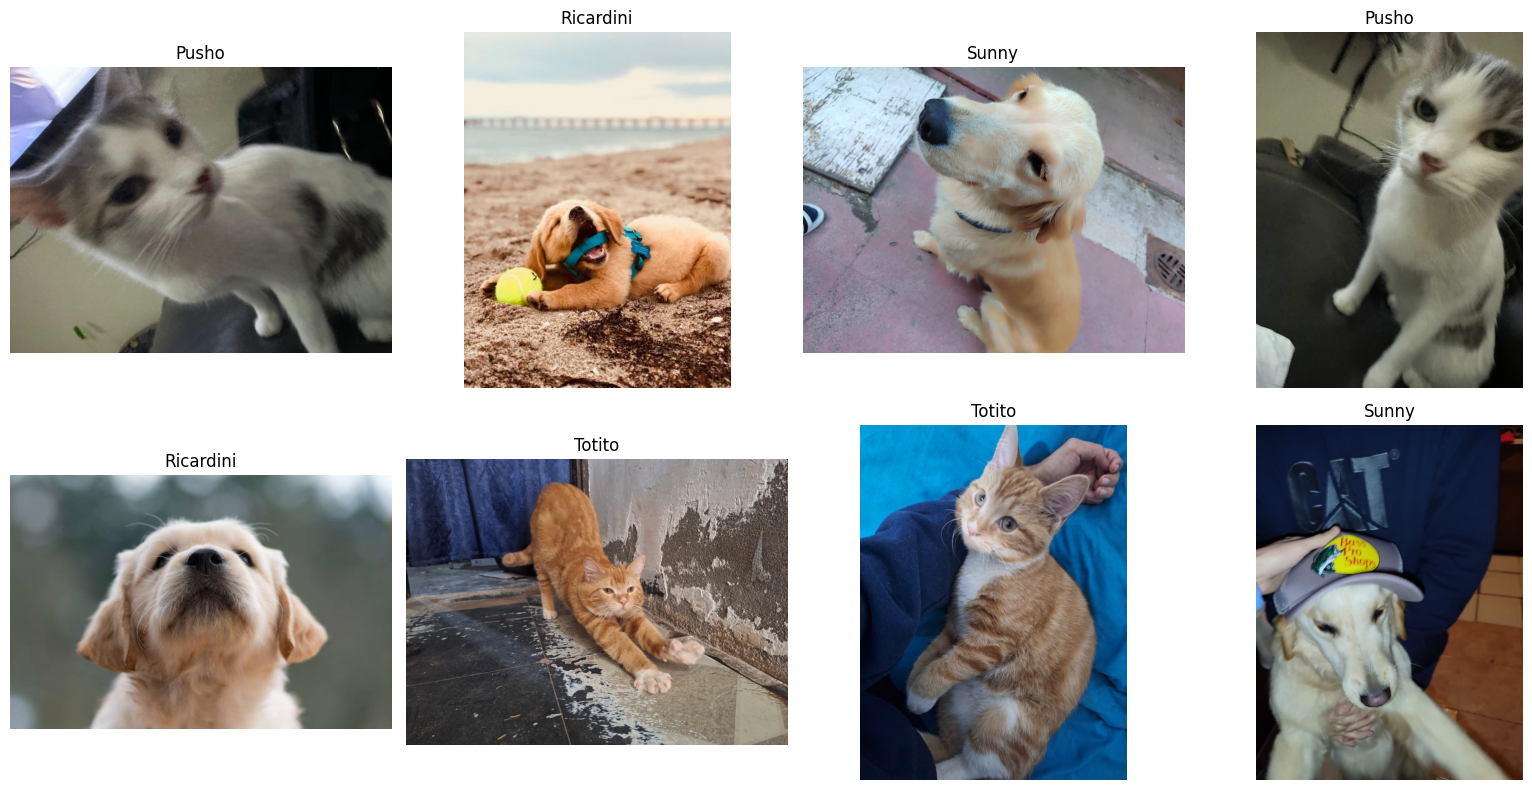

In [10]:
def show_random_images(_samples, _class_names, n=8):
    n = min(n, len(_samples))
    picked = random.sample(_samples, n)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (image_path, label) in enumerate(picked, start=1):
        image = Image.open(image_path).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(image)
        plt.title(_class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_random_images(samples, class_names)


In [11]:
class PetsDataset(Dataset):
    def __init__(self, base_samples, transform=None):
        self.samples = base_samples
        self.transform = transform

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        x = image.to(device)
        y = torch.tensor(label).long().to(device)
        return x, y

    def __len__(self):
        return len(self.samples)


train_data = PetsDataset(train_samples, transform=train_transform)
val_data = PetsDataset(val_samples, transform=eval_transform)
test_data = PetsDataset(test_samples, transform=eval_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


## Training functions

We will use a full mini-batch training loop, track loss and accuracy on both train and validation, and keep the weights from the best validation epoch.


In [12]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state_dict = copy.deepcopy(_model.state_dict())
    best_val_acc = -1.0
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_correct = 0

        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_correct += outputs.argmax(dim=1).eq(y_batch).sum().item()

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = train_correct / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_correct = 0

        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_correct += val_outputs.argmax(dim=1).eq(y_val).sum().item()

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc = val_correct / len(_val_loader.dataset)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_state_dict = copy.deepcopy(_model.state_dict())

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{epoch_val_acc:.4f}",
        )

        res["train_loss"].append(epoch_train_loss)
        res["train_acc"].append(epoch_train_acc)
        res["val_loss"].append(epoch_val_loss)
        res["val_acc"].append(epoch_val_acc)

    _model.load_state_dict(best_state_dict)
    return res


def evaluate(_model, _data_loader, _loss_function):
    _model.eval()
    total_loss = 0.0
    total_correct = 0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in _data_loader:
            output = _model(x)
            total_loss += _loss_function(output, y).item() * x.size(0)

            predictions = output.argmax(dim=1)
            total_correct += predictions.eq(y).sum().item()
            y_true.extend(y.detach().cpu().tolist())
            y_pred.extend(predictions.detach().cpu().tolist())

    return {
        "loss": total_loss / len(_data_loader.dataset),
        "acc": total_correct / len(_data_loader.dataset),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def test(_model, _test_loader, _loss_function):
    res = evaluate(_model, _test_loader, _loss_function)
    return res["loss"], res["acc"]


def plot_learning_curves(_history, _title):
    epochs = range(1, len(_history["train_loss"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, _history["train_loss"], label="Train loss")
    plt.plot(epochs, _history["val_loss"], label="Validation loss")
    plt.title(f"{_title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, _history["train_acc"], label="Train accuracy")
    plt.plot(epochs, _history["val_acc"], label="Validation accuracy")
    plt.title(f"{_title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


## Preparing the pre-trained models

We will use two ImageNet models and train each one with two variants: transfer learning and fine-tuning.


In [13]:
def build_model(model_name, num_classes):
    if model_name == "ResNet18":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model, weights

    if model_name == "MobileNetV3Small":
        weights = MobileNet_V3_Small_Weights.DEFAULT
        model = mobilenet_v3_small(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
        return model, weights

    raise ValueError(f"Unknown model name: {model_name}")


def freeze_all_layers(_model):
    for param in _model.parameters():
        param.requires_grad = False


def prepare_transfer_learning_model(model_name, num_classes):
    model, weights = build_model(model_name, num_classes)
    freeze_all_layers(model)

    if model_name == "ResNet18":
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "MobileNetV3Small":
        for param in model.classifier[-1].parameters():
            param.requires_grad = True

    return model.to(device), weights


def prepare_fine_tuning_model(model_name, transfer_model):
    model = copy.deepcopy(transfer_model)

    if model_name == "ResNet18":
        for param in model.layer4.parameters():
            param.requires_grad = True

    elif model_name == "MobileNetV3Small":
        for block in model.features[-2:]:
            for param in block.parameters():
                param.requires_grad = True

    return model.to(device)


def run_transfer_learning(model_name, num_classes, lr=transfer_learning_rate, epochs=transfer_epochs):
    model, _ = prepare_transfer_learning_model(model_name, num_classes)
    loss_function = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = train(model, train_loader, val_loader, loss_function, optimizer, epochs)
    val_res = evaluate(model, val_loader, loss_function)
    test_res = evaluate(model, test_loader, loss_function)

    metrics = {
        "experiment": f"{model_name} - Transfer learning",
        "model": model_name,
        "variant": "Transfer learning",
        "val_loss": val_res["loss"],
        "val_acc": val_res["acc"],
        "test_loss": test_res["loss"],
        "test_acc": test_res["acc"],
    }

    return model, history, metrics


def run_fine_tuning(model_name, transfer_model, lr=fine_tuning_learning_rate, epochs=fine_tuning_epochs):
    model = prepare_fine_tuning_model(model_name, transfer_model)
    loss_function = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = train(model, train_loader, val_loader, loss_function, optimizer, epochs)
    val_res = evaluate(model, val_loader, loss_function)
    test_res = evaluate(model, test_loader, loss_function)

    metrics = {
        "experiment": f"{model_name} - Fine-tuning",
        "model": model_name,
        "variant": "Fine-tuning",
        "val_loss": val_res["loss"],
        "val_acc": val_res["acc"],
        "test_loss": test_res["loss"],
        "test_acc": test_res["acc"],
    }

    return model, history, metrics


## Training the models


In [14]:
num_classes = len(class_names)


Training: 100%|██████████| 15/15 [00:48<00:00,  3.20s/epoch, train_acc=0.8547, train_loss=0.5775, val_acc=0.8571, val_loss=0.6469]


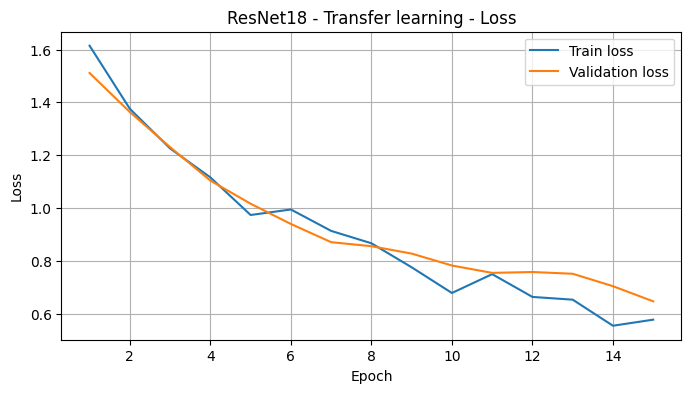

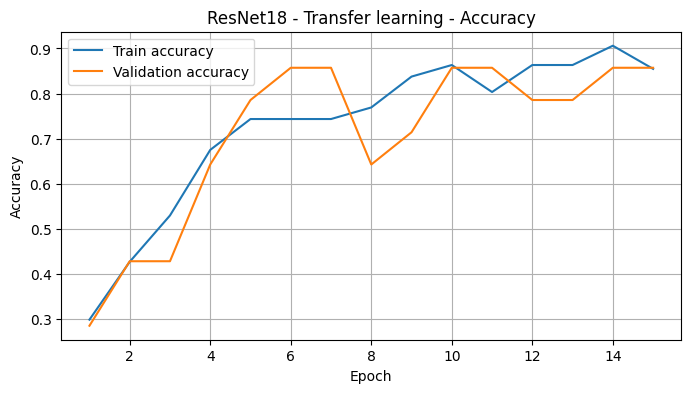

{'experiment': 'ResNet18 - Transfer learning',
 'model': 'ResNet18',
 'variant': 'Transfer learning',
 'val_loss': 0.9397644400596619,
 'val_acc': 0.8571428571428571,
 'test_loss': 0.7178705860586727,
 'test_acc': 0.8823529411764706}

In [15]:
resnet_tl_model, resnet_tl_history, resnet_tl_metrics = run_transfer_learning("ResNet18", num_classes)
plot_learning_curves(resnet_tl_history, "ResNet18 - Transfer learning")
resnet_tl_metrics


Training: 100%|██████████| 12/12 [00:39<00:00,  3.25s/epoch, train_acc=0.9231, train_loss=0.4531, val_acc=0.8571, val_loss=0.5570]


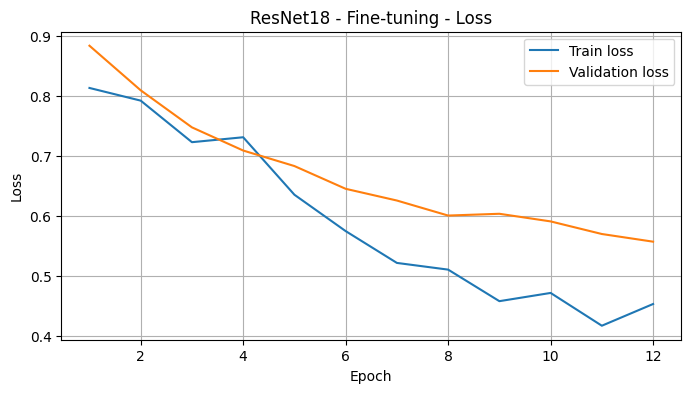

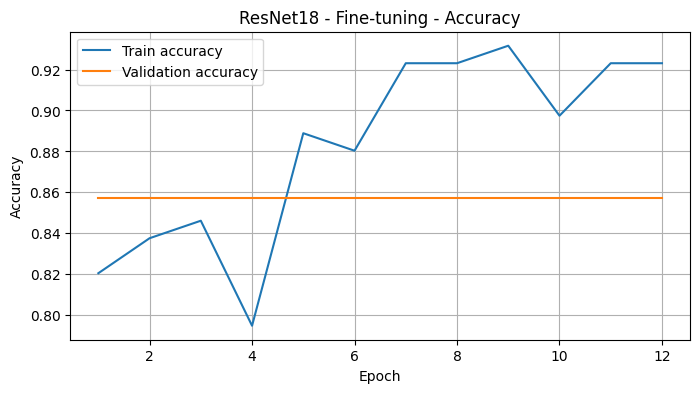

{'experiment': 'ResNet18 - Fine-tuning',
 'model': 'ResNet18',
 'variant': 'Fine-tuning',
 'val_loss': 0.8836739659309387,
 'val_acc': 0.8571428571428571,
 'test_loss': 0.6608846818699556,
 'test_acc': 0.8823529411764706}

In [16]:
resnet_ft_model, resnet_ft_history, resnet_ft_metrics = run_fine_tuning("ResNet18", resnet_tl_model)
plot_learning_curves(resnet_ft_history, "ResNet18 - Fine-tuning")
resnet_ft_metrics


Training: 100%|██████████| 15/15 [00:44<00:00,  2.97s/epoch, train_acc=0.9231, train_loss=0.4768, val_acc=0.8571, val_loss=0.4522]


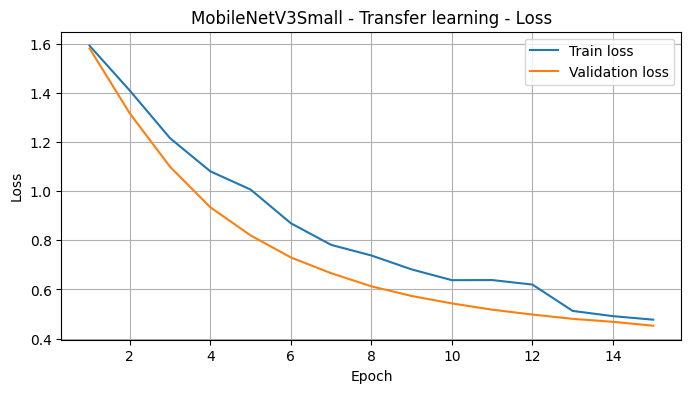

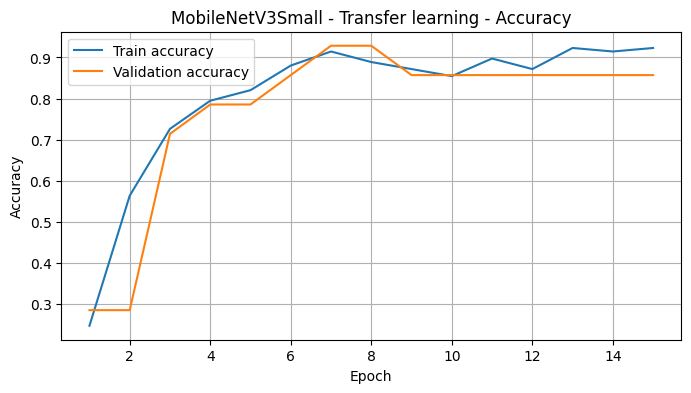

{'experiment': 'MobileNetV3Small - Transfer learning',
 'model': 'MobileNetV3Small',
 'variant': 'Transfer learning',
 'val_loss': 0.6660906076431274,
 'val_acc': 0.9285714285714286,
 'test_loss': 0.5472620445139268,
 'test_acc': 0.8823529411764706}

In [17]:
mobilenet_tl_model, mobilenet_tl_history, mobilenet_tl_metrics = run_transfer_learning("MobileNetV3Small", num_classes)
plot_learning_curves(mobilenet_tl_history, "MobileNetV3Small - Transfer learning")
mobilenet_tl_metrics


Training: 100%|██████████| 12/12 [00:36<00:00,  3.04s/epoch, train_acc=0.8547, train_loss=0.7190, val_acc=0.8571, val_loss=0.6952]


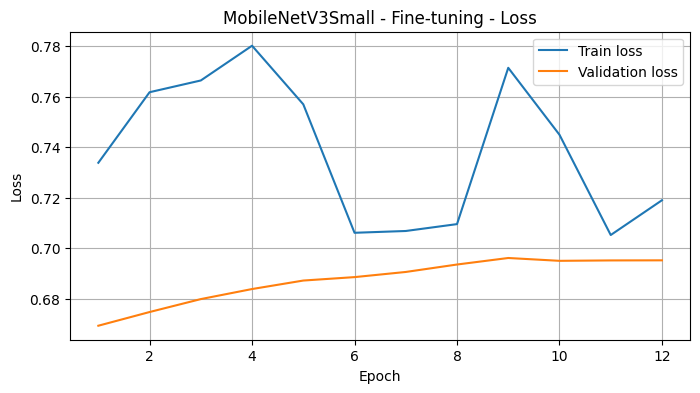

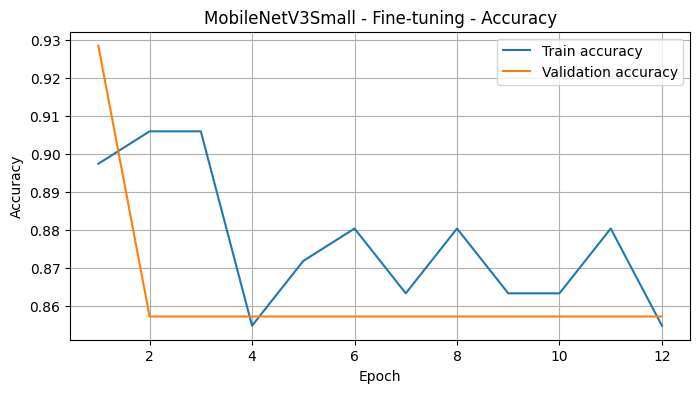

{'experiment': 'MobileNetV3Small - Fine-tuning',
 'model': 'MobileNetV3Small',
 'variant': 'Fine-tuning',
 'val_loss': 0.6693229675292969,
 'val_acc': 0.9285714285714286,
 'test_loss': 0.5497724238563987,
 'test_acc': 0.8823529411764706}

In [18]:
mobilenet_ft_model, mobilenet_ft_history, mobilenet_ft_metrics = run_fine_tuning("MobileNetV3Small", mobilenet_tl_model)
plot_learning_curves(mobilenet_ft_history, "MobileNetV3Small - Fine-tuning")
mobilenet_ft_metrics


## Model comparison

We compare the four trained experiments and select the best one according to validation accuracy.


In [19]:
comparison_df = pd.DataFrame([
    resnet_tl_metrics,
    resnet_ft_metrics,
    mobilenet_tl_metrics,
    mobilenet_ft_metrics,
]).sort_values("val_acc", ascending=False).reset_index(drop=True)
comparison_df


,experiment,model,variant,val_loss,val_acc,test_loss,test_acc
0,MobileNetV3Small - Fine-tuning,MobileNetV3Small,Fine-tuning,0.669323,0.928571,0.549772,0.882353
1,MobileNetV3Small - Transfer learning,MobileNetV3Small,Transfer learning,0.666091,0.928571,0.547262,0.882353
2,ResNet18 - Fine-tuning,ResNet18,Fine-tuning,0.883674,0.857143,0.660885,0.882353
3,ResNet18 - Transfer learning,ResNet18,Transfer learning,0.939764,0.857143,0.717871,0.882353


In [20]:
all_models = {
    resnet_tl_metrics["experiment"]: resnet_tl_model,
    resnet_ft_metrics["experiment"]: resnet_ft_model,
    mobilenet_tl_metrics["experiment"]: mobilenet_tl_model,
    mobilenet_ft_metrics["experiment"]: mobilenet_ft_model,
}

best_experiment = comparison_df.iloc[0]["experiment"]
best_model = all_models[best_experiment]
print("Best model based on validation accuracy:", best_experiment)


Best model based on validation accuracy: MobileNetV3Small - Fine-tuning


## Test evaluation for the best model

The final test report includes accuracy, precision, recall, F1-score, and the confusion matrix.


In [21]:
loss_function = nn.CrossEntropyLoss()
best_test_res = evaluate(best_model, test_loader, loss_function)

y_true = best_test_res["y_true"]
y_pred = best_test_res["y_pred"]

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


Accuracy: 0.8824
Precision: 0.9088
Recall: 0.8824
F1-score: 0.8741

              precision    recall  f1-score   support

       Pusho       1.00      1.00      1.00         5
      Totito       0.75      1.00      0.86         3
   Ricardini       0.80      1.00      0.89         4
       Peque       1.00      0.50      0.67         2
       Sunny       1.00      0.67      0.80         3

    accuracy                           0.88        17
   macro avg       0.91      0.83      0.84        17
weighted avg       0.91      0.88      0.87        17



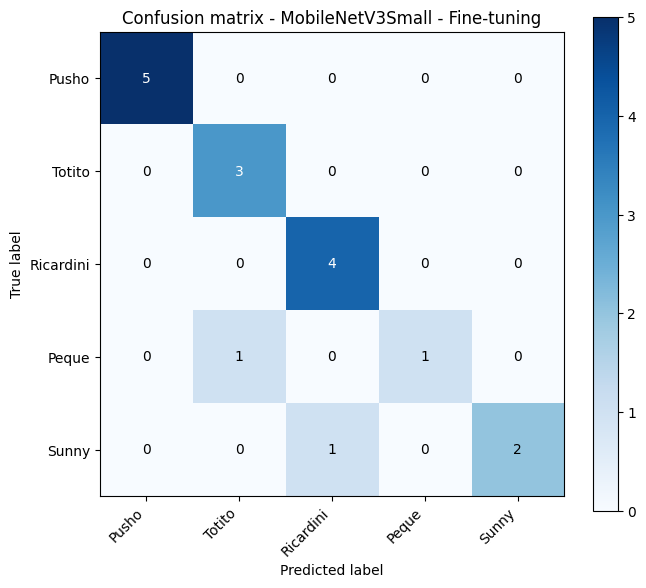

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion matrix - {best_experiment}")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

plt.tight_layout()
plt.show()


## Visual prediction examples

The following cells display random images from the test set and show how each trained model classifies them.

In [23]:
def predict_with_all_models(_image_path, _models, _class_names):
    image = Image.open(_image_path).convert("RGB")
    x = eval_transform(image).unsqueeze(0).to(device)
    results = []

    for experiment_name, model in _models.items():
        model.eval()
        with torch.no_grad():
            output = model(x)
            probabilities = torch.softmax(output, dim=1)
            predicted_label = probabilities.argmax(dim=1).item()
            confidence = probabilities[0, predicted_label].item()

        results.append({
            "experiment": experiment_name,
            "predicted_class": _class_names[predicted_label],
            "confidence": confidence,
        })

    return image, results


def show_visual_predictions(_samples, _class_names, _models, n=6):
    n = min(n, len(_samples))
    picked = random.sample(_samples, n)

    for image_path, label in picked:
        image, results = predict_with_all_models(image_path, _models, _class_names)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 2]})

        axes[0].imshow(image)
        axes[0].set_title(f"True class: {_class_names[label]}")
        axes[0].axis("off")

        axes[1].axis("off")
        lines = []
        for row in results:
            lines.append(
                f'{row["experiment"]}: {row["predicted_class"]} ({row["confidence"]:.4f})'
            )

        axes[1].text(0, 1, "\n".join(lines), va="top", fontsize=11)
        plt.tight_layout()
        plt.show()


def show_visual_predictions_for_class(_samples, _class_names, _models, _target_class, n=5):
    if _target_class not in _class_names:
        print(f"Class not found: {_target_class}")
        return

    target_label = _class_names.index(_target_class)
    filtered_samples = [(image_path, label) for image_path, label in _samples if label == target_label]

    if len(filtered_samples) == 0:
        print(f"No test images found for class: {_target_class}")
        return

    show_visual_predictions(filtered_samples, _class_names, _models, n=n)

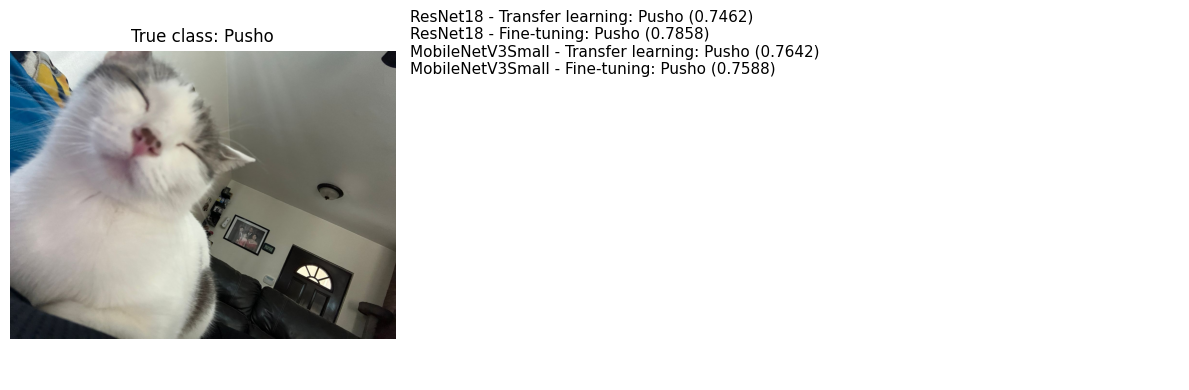

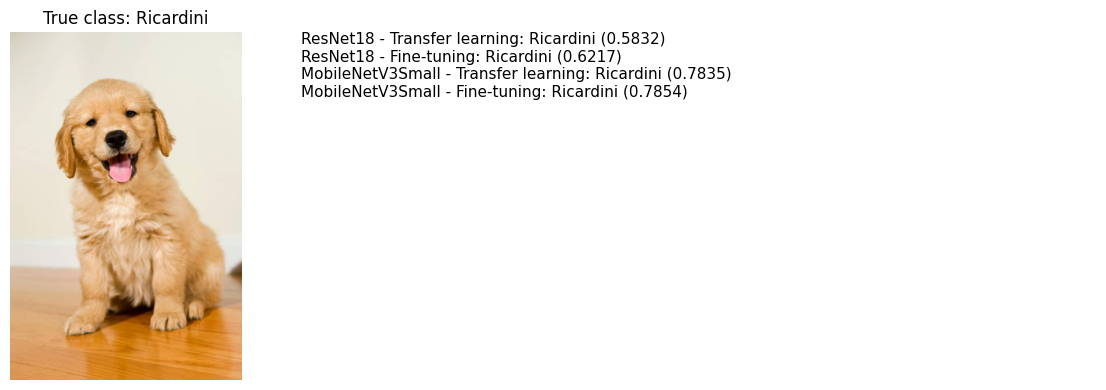

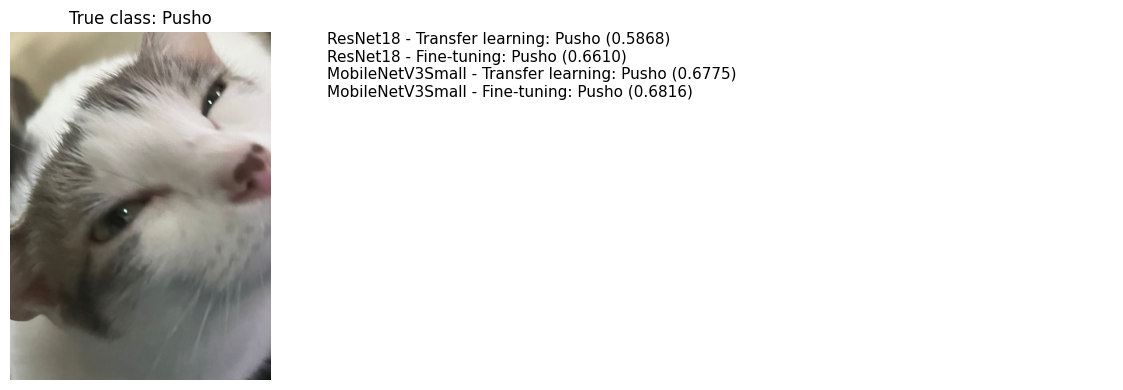

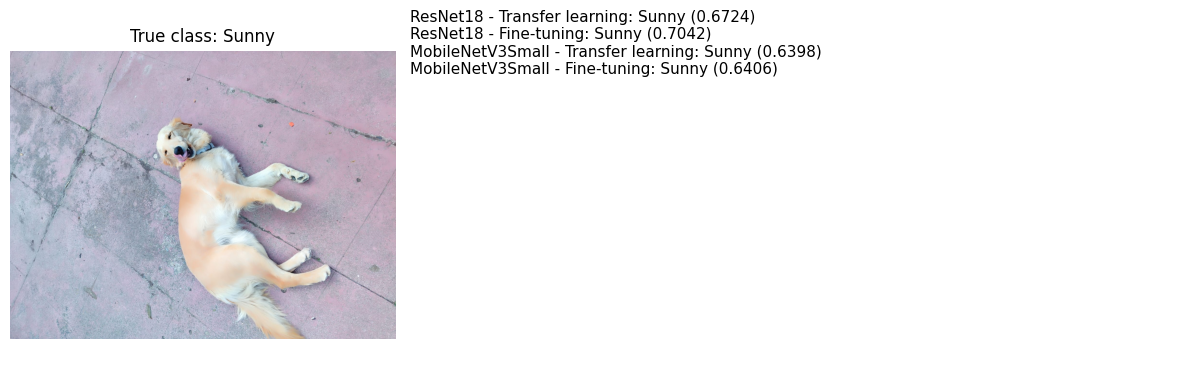

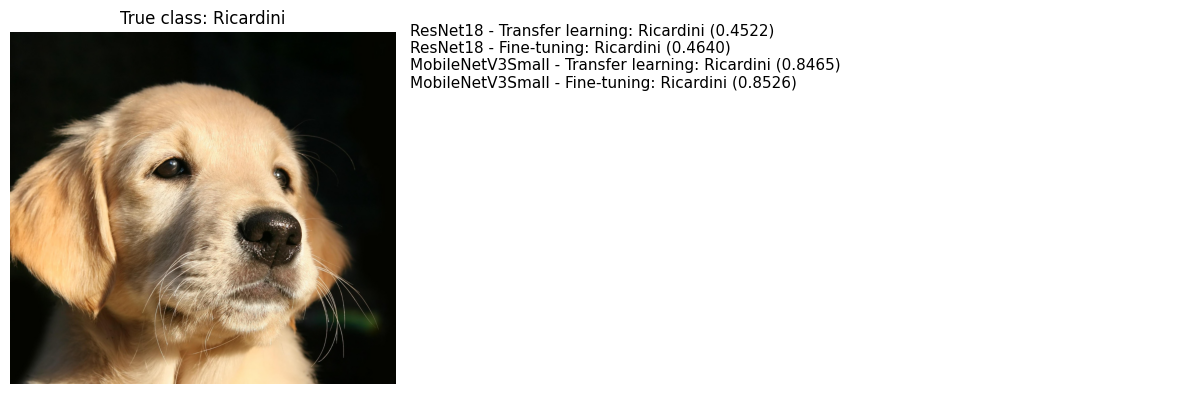

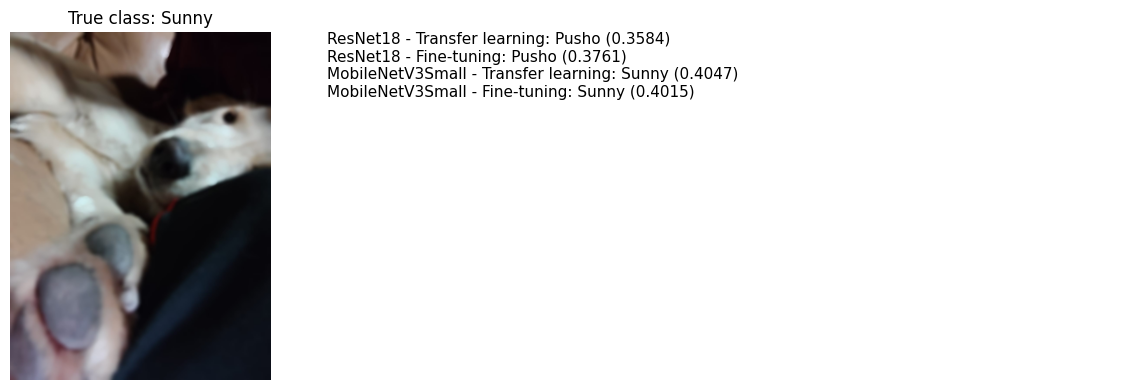

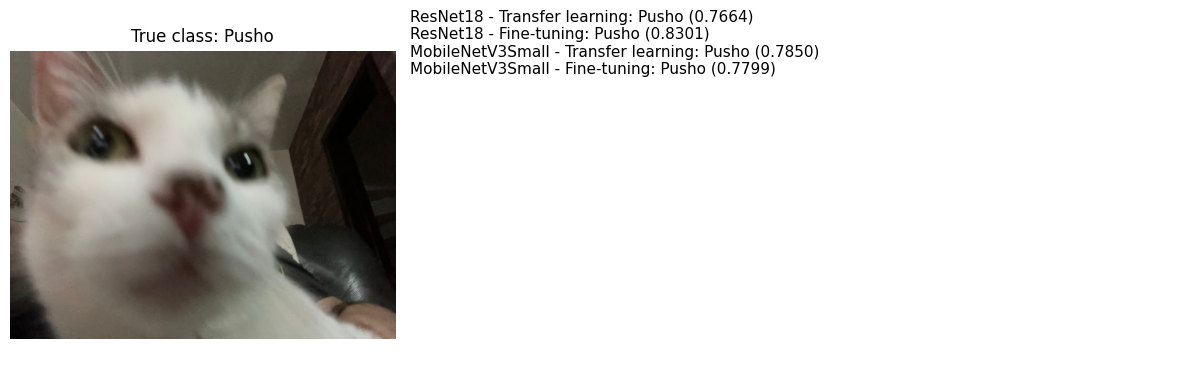

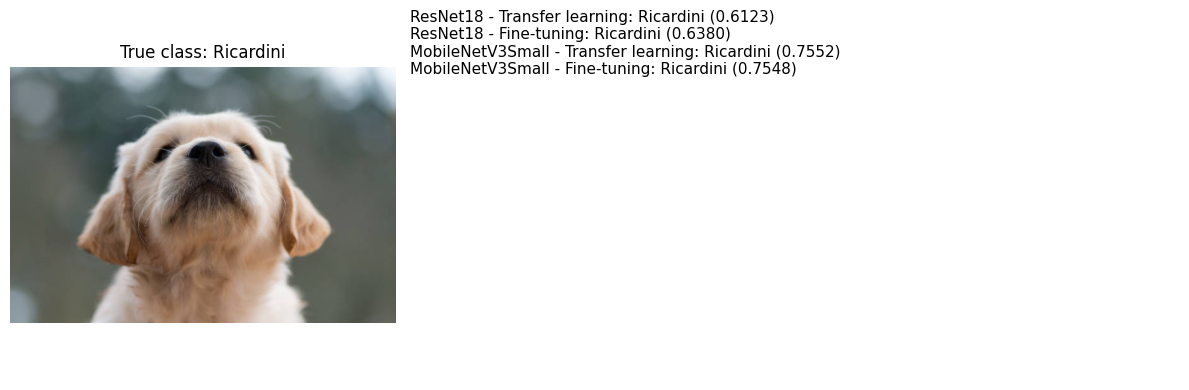

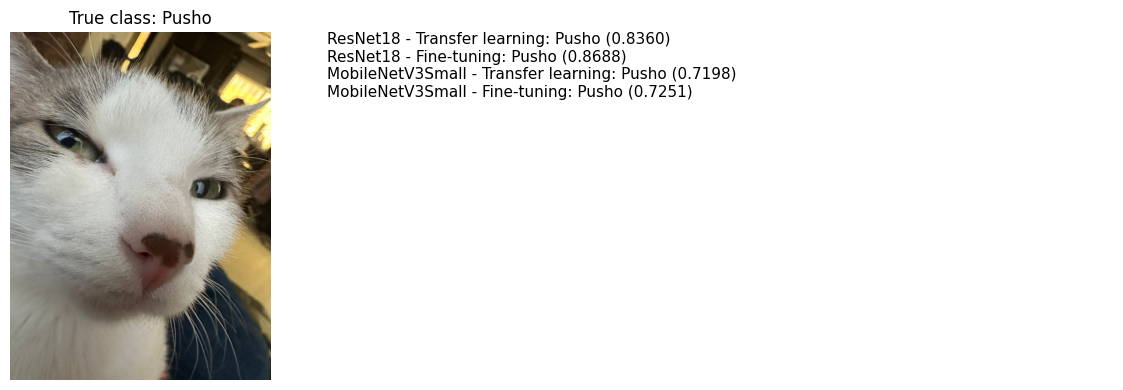

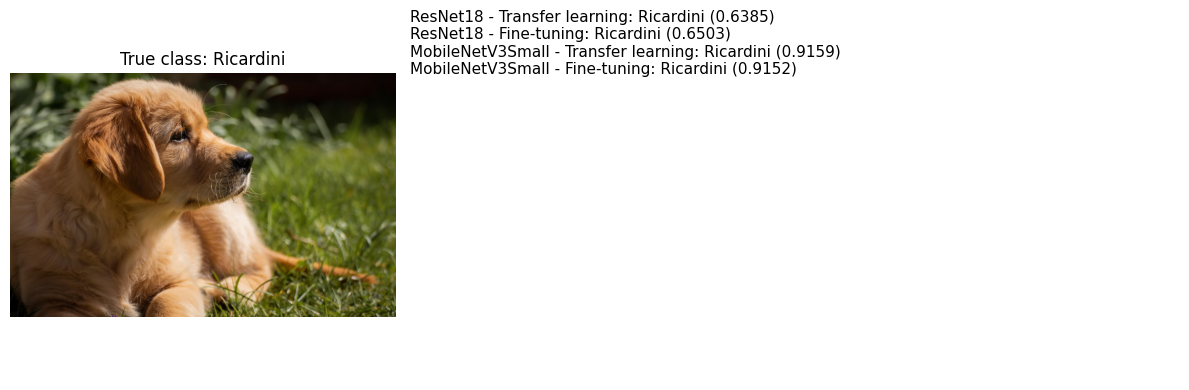

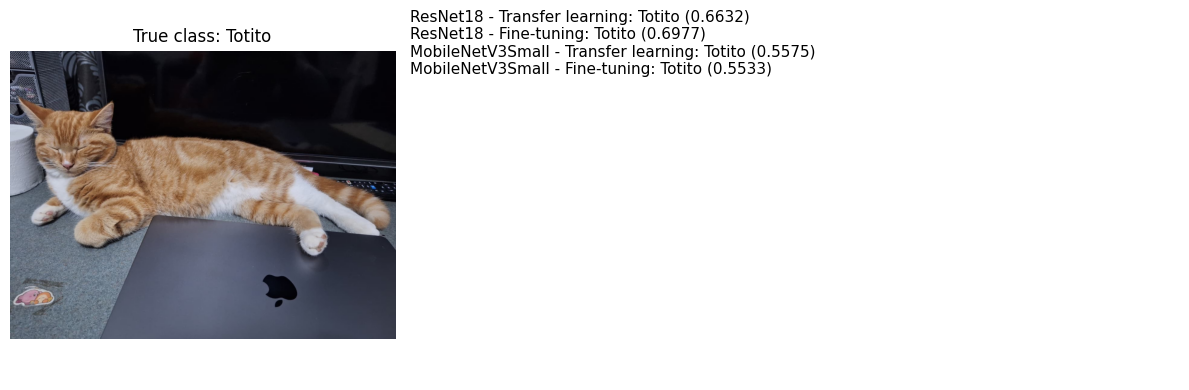

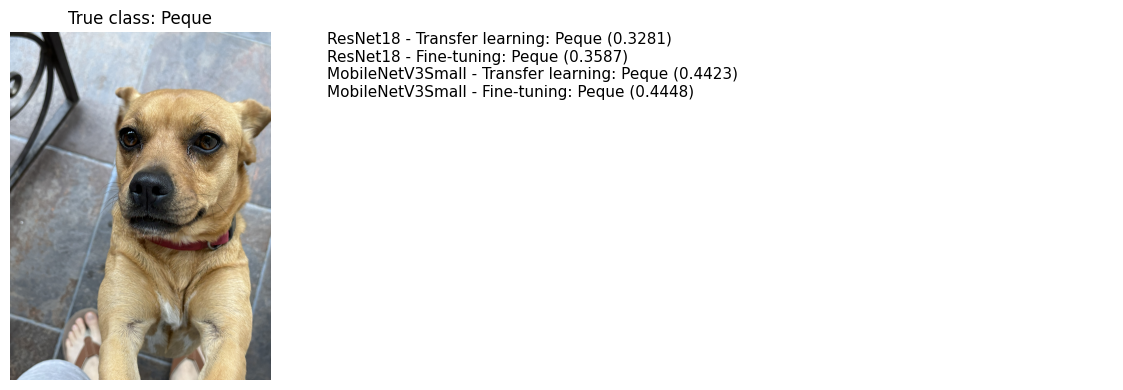

In [24]:
show_visual_predictions(test_samples, class_names, all_models, n=12)

## Visual predictions for images outside the trained classes

The following cells display images from the folder `ningunamascota`. These images are not used during training and are shown only to observe how each trained model classifies images that do not belong to any of the trained pet classes.

In [25]:
def collect_none_pet_samples(_base_path, max_images=30):
    folder_path = _base_path / "ningunamascota"

    if not folder_path.exists():
        print(f"Folder not found: {folder_path}")
        return []

    image_paths = [
        p for p in sorted(folder_path.iterdir())
        if p.is_file() and p.suffix.lower() in valid_extensions
    ]

    if len(image_paths) == 0:
        print(f"No images found in: {folder_path}")
        return []

    rng = random.Random()
    selected_paths = rng.sample(image_paths, k=min(max_images, len(image_paths)))

    return selected_paths


def show_visual_predictions_none_pet(_image_paths, _class_names, _models, n=5):
    if len(_image_paths) == 0:
        print("No images available for ningunamascota.")
        return

    rng = random.Random()
    picked = rng.sample(_image_paths, k=min(n, len(_image_paths)))

    for image_path in picked:
        image, results = predict_with_all_models(image_path, _models, _class_names)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 2]})

        axes[0].imshow(image)
        axes[0].set_title("Image from: ningunamascota")
        axes[0].axis("off")

        axes[1].axis("off")
        lines = []
        for row in results:
            lines.append(
                f'{row["experiment"]}: {row["predicted_class"]} ({row["confidence"]:.4f})'
            )

        axes[1].text(0, 1, "\n".join(lines), va="top", fontsize=11)
        plt.tight_layout()
        plt.show()

In [26]:
none_pet_samples = collect_none_pet_samples(base_path, max_images=30)
print(f"Number of images in ningunamascota for visual testing: {len(none_pet_samples)}")

Number of images in ningunamascota for visual testing: 30


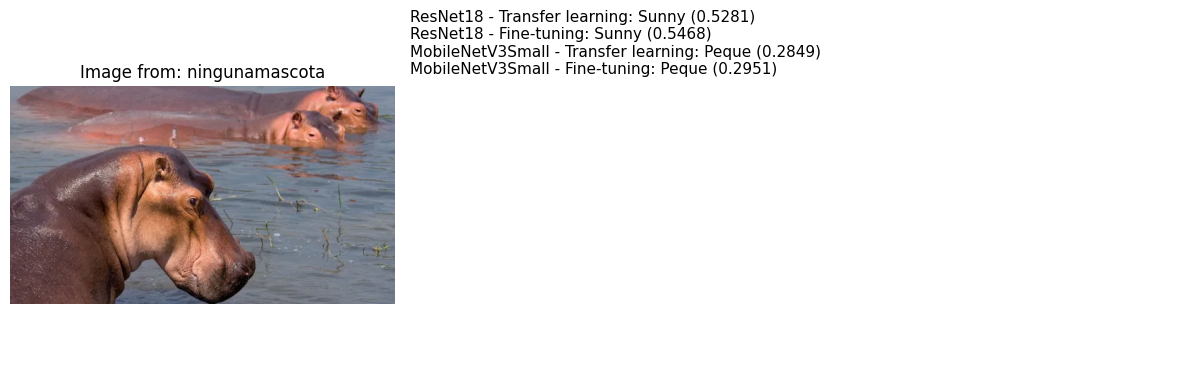

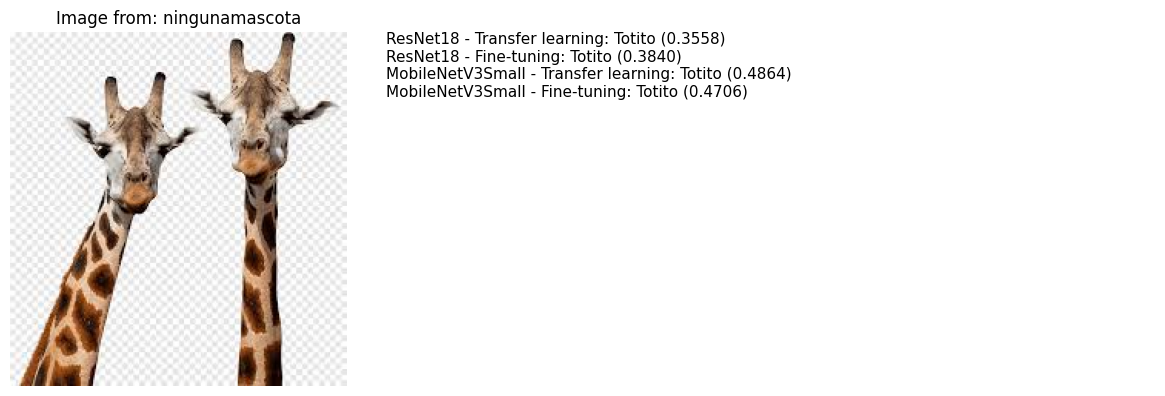

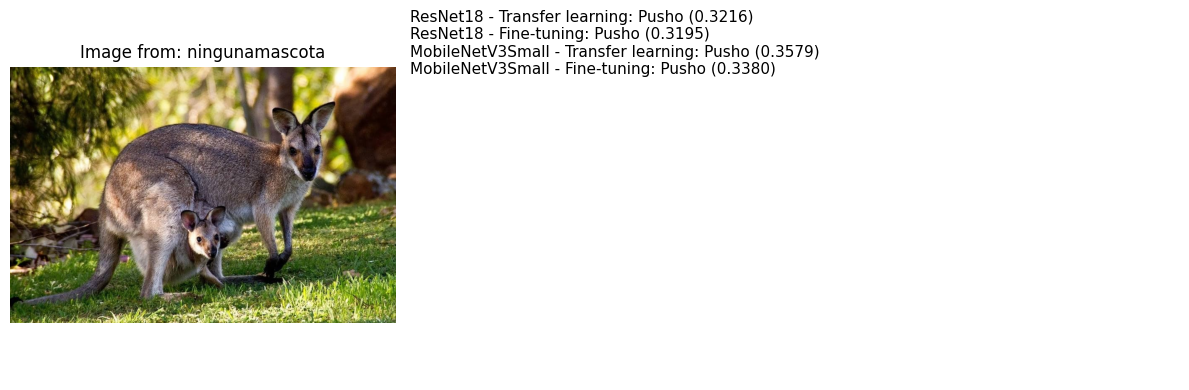

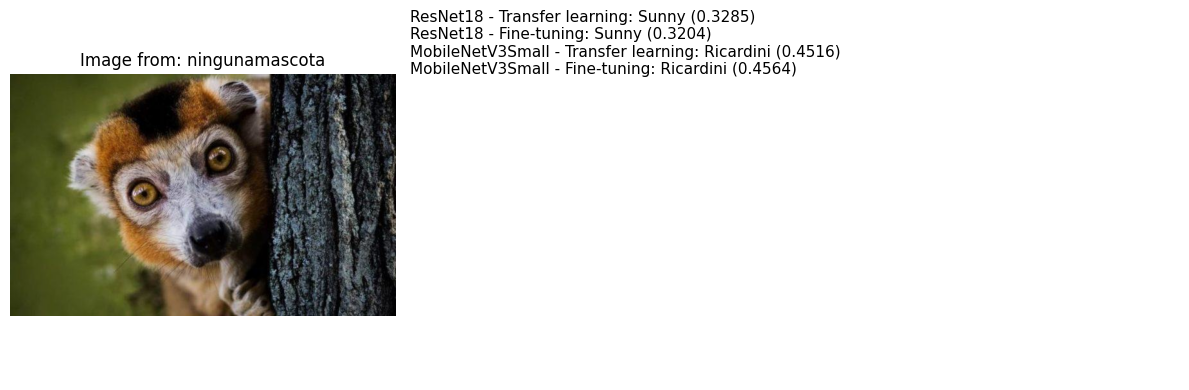

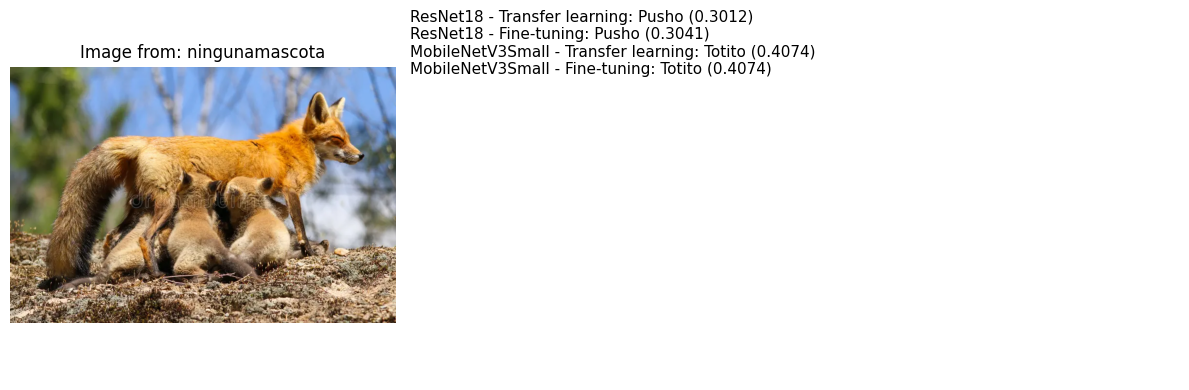

In [27]:
show_visual_predictions_none_pet(none_pet_samples, class_names, all_models, n=5)

## Reflexiones personales


Rafael Negrete Leyva 35322:

Durante esta actividad aprendí que transfer learning y fine-tuning son formas muy útiles de adaptar modelos preentrenados a un problema propio sin tener que entrenar una red neuronal desde cero. En mi caso, trabajar con imágenes reales de mascotas me ayudó a entender que el rendimiento del modelo no depende solamente de la arquitectura, sino también de la calidad, variedad y cantidad del dataset, esto último siendo demasiado relevante es impresiónate lo mucho que cambia al hacer la partición 80, 10,10 si un 10 era solo 1 una imagen realmente sale mal la prueba y el entrenamiento. Con transfer learning observé que el modelo puede aprender razonablemente bien usando solo la nueva capa de salida, lo cual lo vuelve una opción rápida y eficiente cuando se tienen pocos datos o poco tiempo de entrenamiento. Sin embargo, con fine-tuning noté que al descongelar algunas capas del modelo base se puede adaptar mejor a características más específicas del problema, aunque también requiere más cuidado con el learning rate y con el riesgo de sobreajuste. Otra cosa importante que aprendí fue que la evaluación no debe hacerse solo con accuracy, porque al revisar precision, recall, F1-score y la matriz de confusión es más fácil detectar errores entre clases específicas. En general, esta actividad me ayudó a entender mejor la diferencia entre reutilizar conocimiento previo del modelo y ajustarlo más profundamente, y también me hizo ver que en problemas reales la preparación del dataset y la correcta validación son tan importantes como el entrenamiento mismo.

David Emmanuel Santana Romero 35967:

Esta actividad nos mostró a mí y a mi equipo algunas cosas, principalmente la importancia de tener datos orgánicos a la hora de hacer el fine-tuning y el transfer learning, ya que, como podemos ver en las pruebas con imágenes de ninguna mascota, los resultados se ven altamente contaminados, al menos en mi criterio, por las imágenes obtenidas de internet de una forma un tanto heterogénea para la clase Ricardini, que es este un perro hipotético para nuestro compañero Ricardo, ya que Ricardo, pues, no tiene mascotas, como el resto de nosotros. Entonces, eso. Lo otro es que modelar lo que no es el resto de las clases es bastante complicado, pues, muchísimo más complicado que tratar de modelar aquello que sí es. Entonces, bueno, teniendo unas cuantas clases de dónde elegir y clases tan variadas, como lo son nuestras cinco mascotas, el modelo tiene complicaciones, tanto ResNet como MobileNet, para discernir que no se trata de ninguna de ellas. Al menos no con la suficiente distinción respecto de cuando sí se trata de estas mascotas. Encontramos muy relevante para el trabajo que, pese a las distintas poses en las que pudiéramos encontrar a nuestras mascotas y por las que de hecho son tan curiosas que se tomaron estas fotografías en primer lugar, los modelos en su mayoría logran distinguir de cuál se trata acertando en la mayoría en las cuatro instancias y teniendo unas leves discrepancias únicamente cuando se cubre parcialmente el rostro de alguno de ellos, como es en el caso de mi gato Totito. y bueno, le veo bastante potencial a esta idea como para aplicar esto en un sistema de monitoreo de hogar, quizá para saber en todo momento dónde están las mascotas o qué están haciendo. Es bastante curioso, bastante útil poder aplicar machine learning a pues a ser tan cercanos.